                                                 Random Forest Classifier with morphological Features

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
#  Load Data 
df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\MyTable_1_TwinkleKashyap.csv")


df.drop('objid', axis=1, inplace=True)

np.random.seed(42)
random.seed(42)

#  Feature Engineering 
# Color features 
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

#  data cleaning
df = df[(df['u_g'] > -5) & (df['u_g'] < 5) &
        (df['g_r'] > -5) & (df['g_r'] < 5)]


In [3]:
df[['psf_model_diff_r', 'petro_exp_ratio_r']].describe()

,psf_model_diff_r,petro_exp_ratio_r
count,99354.000000,9.935400e+04
mean,0.676925,1.135732e+04
std,0.716236,4.372107e+05
min,-1.735756,7.615927e-03
25%,0.011534,2.726091e+00
50%,0.577896,4.202887e+00
75%,1.132624,1.505359e+01
max,7.447768,6.817986e+07


In [4]:
#  Encode Labels 
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

#  Features & Target 
X = df.drop('class', axis=1)
y = df['class']


from imblearn.over_sampling import SMOTE

#  Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Smote 
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [5]:
# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
# Predictions 
y_pred = rf.predict(X_test)


In [27]:
# Evaluation 
print("WITH REDSHIFT")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

WITH REDSHIFT
Accuracy: 0.9829905726842688
[[16758   141    98]
 [  265  3820     0]
 [    3     0  8722]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     16997
           1       0.96      0.94      0.95      4085
           2       0.99      1.00      0.99      8725

    accuracy                           0.98     29807
   macro avg       0.98      0.97      0.98     29807
weighted avg       0.98      0.98      0.98     29807



In [28]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

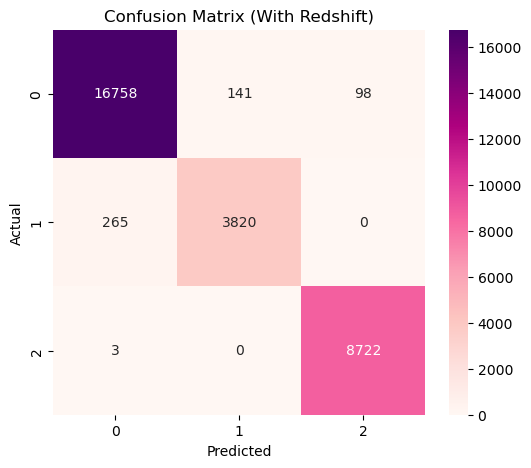

In [29]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (With Redshift)")

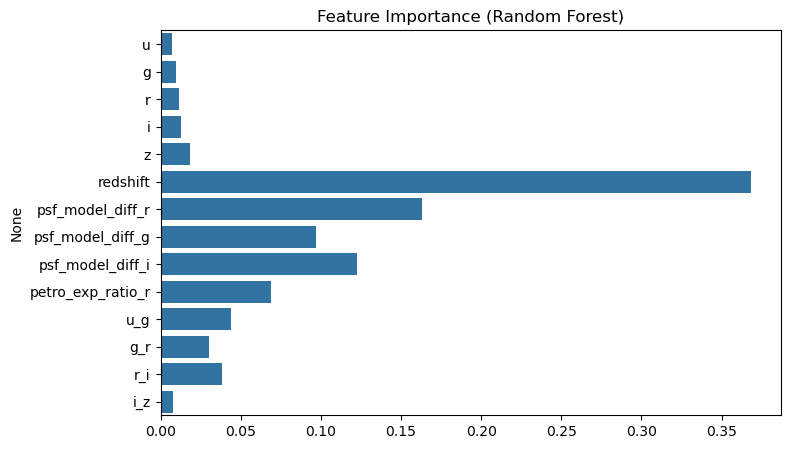

In [30]:
importances = rf.feature_importances_

# feature names 
feature_names = df.drop('class', axis=1).columns

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.show()

                                                        Without Redshift

In [31]:
X_no_z = X.drop('redshift', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_no_z, y, test_size=0.3, random_state=42
)

In [32]:
#  Random Forest Model 
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred = rf.predict(X_test)

In [34]:
print("\nWITHOUT REDSHIFT")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


WITHOUT REDSHIFT
Accuracy: 0.9221659341765357
[[16564   206   227]
 [  352  2977   756]
 [  305   474  7946]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     16997
           1       0.81      0.73      0.77      4085
           2       0.89      0.91      0.90      8725

    accuracy                           0.92     29807
   macro avg       0.89      0.87      0.88     29807
weighted avg       0.92      0.92      0.92     29807



In [35]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

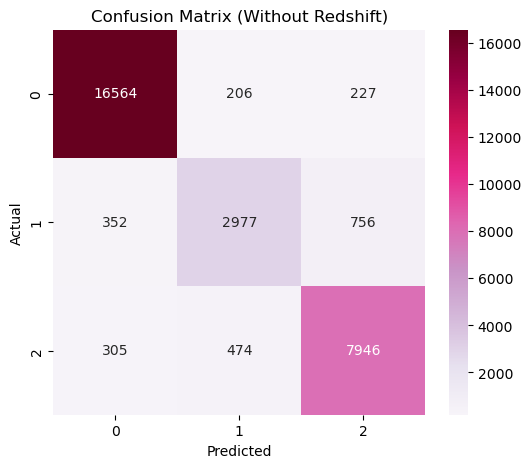

In [36]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (Without Redshift)")

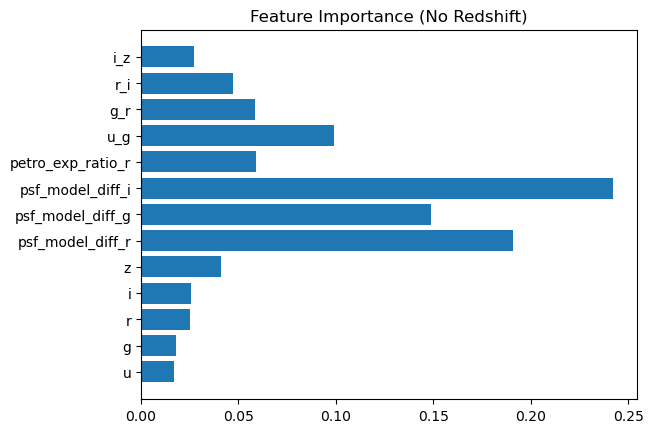

In [37]:
import matplotlib.pyplot as plt
features = X_no_z.columns
importances = rf.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance (No Redshift)")
plt.show()

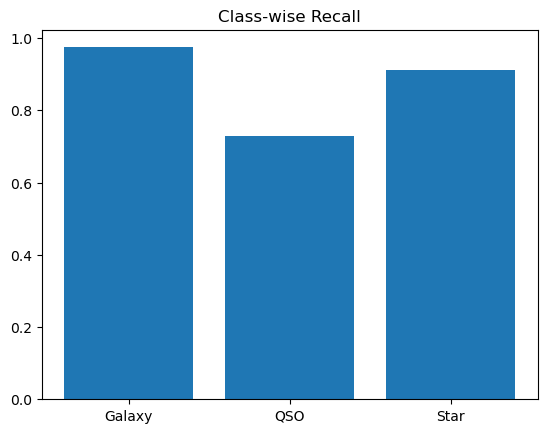

In [38]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

recalls = [report[str(i)]['recall'] for i in range(3)]

plt.bar(['Galaxy','QSO','Star'], recalls)
plt.title("Class-wise Recall")
plt.show()